### Los modelos de regresion permiten predecir valores numericos continuos mediante tecnicas matematicas y estadisticas
* MAE
* MSE
* RMSE
* R²

### Problema:
Una empresa de telecomunicaciones desea estimar cuanto dinero generará un cliente, considerando lass variables de 
* permanencia de un cliente, 
* cargos mensuales (monthlyCharges)
* Tipo de contrato
* tipo de servicio de internet
La variable a predecir es totalCharges

# 1. Importación de librerías


In [96]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# División de datos
from sklearn.model_selection import train_test_split

# Modelo de regresión
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 2. Carga de DataSet

In [97]:
datos = pd.read_csv("telecom_churn_b.csv")

# Mostrar primeras filas
display(datos.head())

,gender,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,Male,4.0,34.69,102.71,Two year,Fiber optic123,1.0
1,Male,55.0,56.56,3084.07,Month-to-month,DSL,0.0
2,Male,70.0,56.95,3964.32,One year@@,DSL,0.0
3,Male,55.0,39.33,2208.87,One year,Fiber optic,0.0
4,Male,49.0,109.32,5367.05,Month-to-month,Fiber optic,0.0


# 3. Exploración inicial

In [98]:
print("\n INFORMACION DEL DATASET")
print("===================================\n")
print(datos.info())

print("\n ESTADISTICAS DEL DATA SET")
print("===================================\n")
display(datos.describe())

print("\n VALORES NULOS POR CAMPO")
print("===================================\n")
print(datos.isnull().sum())


 INFORMACION DEL DATASET

<class 'pandas.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1143 non-null   str    
 1   tenure           1151 non-null   float64
 2   MonthlyCharges   1151 non-null   float64
 3   TotalCharges     1152 non-null   float64
 4   Contract         1149 non-null   str    
 5   InternetService  1210 non-null   str    
 6   Churn            1210 non-null   float64
dtypes: float64(4), str(3)
memory usage: 66.3 KB
None

 ESTADISTICAS DEL DATA SET



,tenure,MonthlyCharges,TotalCharges,Churn
count,1151.000000,1151.000000,1152.000000,1210.000000
mean,15308.817566,14298.231238,17939.718667,16230.536602
std,111141.166139,109243.545345,118696.730130,115805.571852
min,-999.000000,-999.000000,-999.000000,-999.000000
25%,19.000000,44.625000,1030.377500,0.000000
50%,37.000000,64.500000,2094.785000,0.000000
75%,57.000000,82.195000,3457.662500,1.000000
max,999999.000000,999999.000000,999999.000000,999999.000000



 VALORES NULOS POR CAMPO

gender             67
tenure             59
MonthlyCharges     59
TotalCharges       58
Contract           61
InternetService     0
Churn               0
dtype: int64


In [99]:
# REGISTROS DUPLICADOS
duplicados = datos.duplicated().sum()

print(f"\nCantidad de filas duplicadas: {duplicados}")

# VALORES ÚNICOS
print("\nCantidad de valores únicos por columna:")
display(datos.nunique())

# DETECCIÓN DE OUTLIERS (RUIDO)
# Método IQR
columnas_numericas = datos.select_dtypes(include=np.number).columns

outliers = {}

for col in columnas_numericas:
    
    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    cantidad = datos[
        (datos[col] < limite_inferior) |
        (datos[col] > limite_superior)
    ].shape[0]
    
    outliers[col] = cantidad

print("\nCantidad de outliers por columna:")
display(pd.DataFrame(outliers.items(), columns=["Columna", "Outliers"]))

# VARIABLES CATEGÓRICAS
categoricas = datos.select_dtypes(include='object').columns

for col in categoricas:
    print(f"\nFrecuencia de valores en: {col}")
    display(datos[col].value_counts())


Cantidad de filas duplicadas: 5

Cantidad de valores únicos por columna:


gender               19
tenure               90
MonthlyCharges     1038
TotalCharges       1114
Contract             29
InternetService      26
Churn                21
dtype: int64


Cantidad de outliers por columna:


,Columna,Outliers
0,tenure,40
1,MonthlyCharges,40
2,TotalCharges,33
3,Churn,40



Frecuencia de valores en: gender


...

gender
Female       540
Male         524
FEMALE        13
Female???      9
Male@@         8
 Female        6
Female###      6
Female@@       5
male           5
female         5
 Male          5
Male###        3
Female123      3
MALE           3
Male123        2
Male???        2
NAN            2
female###      1
nan@@          1
Name: count, dtype: int64


Frecuencia de valores en: Contract


Contract
Two year             361
Month-to-month       353
One year             352
 One year              7
one year               6
One year@@             5
two year               5
One_year               5
One year???            5
month-to-month         4
Month-to-month???      4
 Month-to-month        4
Month-to-month###      4
One year###            4
Two year???            4
Two year123            3
Two year###            3
MONTH-TO-MONTH         3
Two_year               3
TWO YEAR               3
Month-to-month@@       2
ONE YEAR               2
 Two year ###          1
 nan                   1
One year123            1
Two_year123            1
Two year@@             1
two year###            1
nan???                 1
Name: count, dtype: int64


Frecuencia de valores en: InternetService


InternetService
Fiber optic       405
No                366
DSL               365
 No                 7
no                  5
DSL@@               5
fiber optic         5
No123               5
No@@                5
DSL###              5
Fiber optic@@       5
FIBER OPTIC         4
DSL???              4
NO                  3
Fiber_optic         3
 Fiber optic        3
Fiber optic123      2
dsl                 2
No###               2
Fiber optic###      2
 DSL                2
NO123               1
DSL123              1
no@@                1
Fiber optic???      1
No???               1
Name: count, dtype: int64

# 4. Preprocesamiento de datos
## Codificaci´ñon de variables
# Eliminar datos nulos

In [100]:
datos = datos.dropna()
print("\n VALORES NULOS ELIMINADOS ====>\n")


 VALORES NULOS ELIMINADOS ====>



## Eliminación de valores duplicados

In [101]:
datos = datos.drop_duplicates()
print("\n VALORES DUPLICADOS ELIMINADOS ====>\n")


 VALORES DUPLICADOS ELIMINADOS ====>



## Conversión de variables

In [102]:
encoder = LabelEncoder()

datos["gender"] = encoder.fit_transform(
    datos["gender"]
)

datos["Contract"] = encoder.fit_transform(
    datos["Contract"]
)

datos["InternetService"] = encoder.fit_transform(
    datos["InternetService"]
)
# Convertir variables categóricas a variables dummy

#datos = pd.get_dummies(
#    datos,
#    columns=[
#        "gender",
#        "Contract",
#        "InternetService"
#    ],
#    drop_first=True
#)
print("\n CONVERSIONES REALIZADOS ====>\n")
display(datos.head())


 CONVERSIONES REALIZADOS ====>



,gender,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,9,4.0,34.69,102.71,16,10,1.0
1,9,55.0,56.56,3084.07,4,3,0.0
2,9,70.0,56.95,3964.32,13,3,0.0
3,9,55.0,39.33,2208.87,9,8,0.0
4,9,49.0,109.32,5367.05,4,8,0.0


# 5. Selección de variables
Variables independientes (X)

In [103]:
X = datos[
    [
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService"
    ]
]
print("\n DEFINIDO VARIABLES INDEPENDIANTES ====>\n")
print(f"{X}")


 DEFINIDO VARIABLES INDEPENDIANTES ====>

      tenure  MonthlyCharges  Contract  InternetService
0        4.0           34.69        16               10
1       55.0           56.56         4                3
2       70.0           56.95        13                3
3       55.0           39.33         9                8
4       49.0          109.32         4                8
...      ...             ...       ...              ...
1195    54.0           36.29         9                3
1196    29.0           65.61         4               16
1197    62.0           68.44        16                8
1198    47.0           75.05         6                3
1199    25.0           74.76        16               16

[935 rows x 4 columns]


## Variables dependientes (Y)

In [104]:
y = datos["TotalCharges"]
print("\n DEFINIDO VARIABLE DEPENDIENTE ====>\n")
print(f"{y}")


 DEFINIDO VARIABLE DEPENDIENTE ====>

0        102.71
1       3084.07
2       3964.32
3       2208.87
4       5367.05
         ...   
1195    1997.27
1196    1875.72
1197    4230.87
1198    3532.82
1199    1854.99
Name: TotalCharges, Length: 935, dtype: float64


# 6. División de datos
Se divide el dataset
* 80% entrenamiento
* 20% prueba

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\n REALIZADO LA DIVISION 80% PARA EL ENTRENAMIENTO, 20% PARA PRUEBA\n")


 REALIZADO LA DIVISION 80% PARA EL ENTRENAMIENTO, 20% PARA PRUEBA



In [106]:
print("===== TAMAÑO DE LOS DATOS =====\n")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

===== TAMAÑO DE LOS DATOS =====

X_train: (748, 4)
X_test : (187, 4)
y_train: (748,)
y_test : (187,)


# 7. Normalización de datos
* Estabilidad matemática
* presición
* convergencia del modelo

In [107]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\n NORMALIZACION REALIZADO ====>\n")


 NORMALIZACION REALIZADO ====>



# 8. Creación del modelo de Regresión
## Se usará Regresión Lineal: $y = mx + b$
* el algoritmo analiza patrones
* ajusta los coeficientes
* minimiza errores
* genera una función matemática predictiva

In [108]:
modelo = LinearRegression()

# Entrenamiento
modelo.fit(
    X_train,
    y_train
)

print("\nMODELO DE REGRESION CREADO ====>\n")


MODELO DE REGRESION CREADO ====>



# 9. Predicciones

In [109]:
predicciones = modelo.predict(X_test)

print("\nPRIMEROS N PREDICCIONES ====>\n")
print(predicciones[:10])


PRIMEROS N PREDICCIONES ====>

[14784.14453916 20765.36248092 20765.29143059 21804.70171357
 14784.02680822 13744.45731472 13744.71520904 14784.20596357
 13002.9387309  19103.9588949 ]


## Comparación de valores reales VS predicciones

In [110]:
comparacion = pd.DataFrame({
    "Valor Real": y_test.values,
    "Predicción": predicciones
})
print("\nVALORES REALES vs PREDICCIONES ====>\n")
print(comparacion.head(10))


VALORES REALES vs PREDICCIONES ====>

   Valor Real    Predicción
0     1675.98  14784.144539
1     1402.01  20765.362481
2      754.18  20765.291431
3      385.42  21804.701714
4     1904.71  14784.026808
5     5580.80  13744.457315
6     5274.27  13744.715209
7      990.41  14784.205964
8     1975.81  13002.938731
9     1587.58  19103.958895


## Gráfico de los valores reales VS predicciones

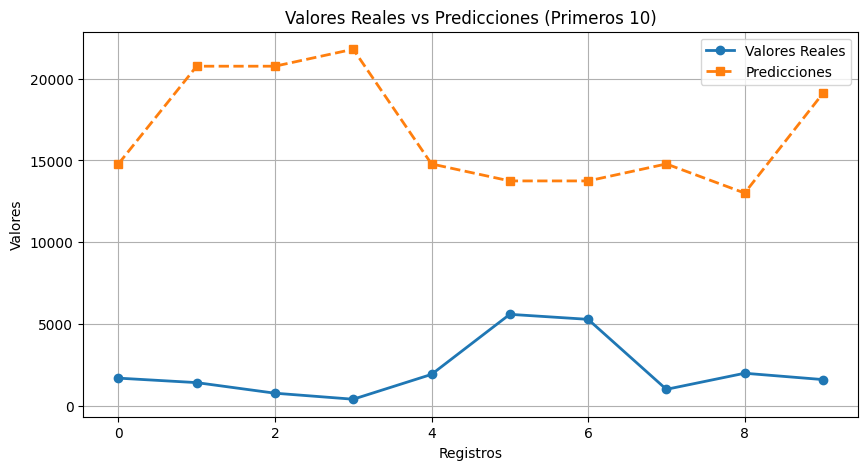

In [111]:
comparacion = pd.DataFrame({
    "Valor Real": y_test.values,
    "Predicción": predicciones
})

# Seleccionar solo los primeros 10 registros
comparacion_10 = comparacion.head(10)

# GRÁFICO DE REGRESIÓN

plt.figure(figsize=(10,5))

# Valores reales
plt.plot(
    comparacion_10["Valor Real"],
    marker='o',
    linewidth=2,
    label="Valores Reales"
)

# Valores predichos
plt.plot(
    comparacion_10["Predicción"],
    marker='s',
    linestyle='--',
    linewidth=2,
    label="Predicciones"
)

# PERSONALIZACIÓN

plt.title("Valores Reales vs Predicciones (Primeros 10)")
plt.xlabel("Registros")
plt.ylabel("Valores")

plt.legend()
plt.grid(True)

plt.show()

* Si es buen ajuste, el modelo presenta lineas muy similares
* Si las lineas están separadas, entonces existe un mal ajuste

# 10. Evaluación del modelo

## MAE mide promedio absoluto de errores

In [112]:
from sklearn.metrics import mean_absolute_error

# Calcular MAE
mae = mean_absolute_error(
    y_test,
    predicciones
)

# Mostrar resultado
print("\n=== ERROR ABSOLUTO MEDIO (MAE) ===\n")
print(f"MAE: {mae:.4f}")

# INTERPRETACIÓN DEL MAE

print("\n=== INTERPRETACIÓN ===\n")

print(
    f"El modelo presenta un error promedio de {mae:.4f} unidades "
    "entre los valores reales y las predicciones."
)

if mae < 1:
    print("Interpretación: El modelo posee una precisión MUY ALTA.")
elif mae < 5:
    print("Interpretación: El modelo posee una buena precisión predictiva.")
elif mae < 10:
    print("Interpretación: El modelo presenta una precisión aceptable.")
else:
    print("Interpretación: El modelo presenta errores elevados y requiere mejoras.")


=== ERROR ABSOLUTO MEDIO (MAE) ===

MAE: 28691.3699

=== INTERPRETACIÓN ===

El modelo presenta un error promedio de 28691.3699 unidades entre los valores reales y las predicciones.
Interpretación: El modelo presenta errores elevados y requiere mejoras.


# Error cuadrático medio

In [113]:
from sklearn.metrics import mean_squared_error

# Calcular MSE
mse = mean_squared_error(
    y_test,
    predicciones
)

# MOSTRAR RESULTADOS

print("\n=== ERROR CUADRÁTICO MEDIO (MSE) ===\n")
print(f"MSE: {mse:.4f}")

# INTERPRETACIÓN DEL MSE

print("\n=== INTERPRETACIÓN ===\n")

print(
    f"El modelo presenta un Error Cuadrático Medio (MSE) de {mse:.4f}. "
    "Esta métrica mide el promedio de los errores al cuadrado entre "
    "los valores reales y las predicciones generadas por el modelo."
)

print(
    "\nUn valor bajo de MSE indica que las predicciones son cercanas "
    "a los valores reales, mientras que valores altos reflejan "
    "mayor diferencia y menor precisión predictiva."
)

# Interpretación automática
if mse < 1:
    print("\nInterpretación: El modelo posee un desempeño EXCELENTE.")
elif mse < 10:
    print("\nInterpretación: El modelo presenta un buen nivel de precisión.")
elif mse < 50:
    print("\nInterpretación: El modelo tiene una precisión aceptable.")
else:
    print("\nInterpretación: El modelo presenta errores elevados y requiere optimización.")


=== ERROR CUADRÁTICO MEDIO (MSE) ===

MSE: 12570828482.0030

=== INTERPRETACIÓN ===

El modelo presenta un Error Cuadrático Medio (MSE) de 12570828482.0030. Esta métrica mide el promedio de los errores al cuadrado entre los valores reales y las predicciones generadas por el modelo.

Un valor bajo de MSE indica que las predicciones son cercanas a los valores reales, mientras que valores altos reflejan mayor diferencia y menor precisión predictiva.

Interpretación: El modelo presenta errores elevados y requiere optimización.


# Raiz del error cuadrático medio (RMSE)

In [114]:
# Calcular RMSE
rmse = np.sqrt(mse)

# MOSTRAR RESULTADOS

print("\n=== RAÍZ DEL ERROR CUADRÁTICO MEDIO (RMSE) ===\n")
print(f"RMSE: {rmse:.4f}")

# INTERPRETACIÓN DEL RMSE

print("\n=== INTERPRETACIÓN ===\n")

print(
    f"El modelo presenta un RMSE de {rmse:.4f}. "
    "Esta métrica representa el promedio del error de predicción "
    "en las mismas unidades de la variable objetivo."
)

# INTERPRETACIÓN AUTOMÁTICA

if rmse < 1:
    print("\nInterpretación Automática: El modelo posee un desempeño EXCELENTE.")
elif rmse < 5:
    print("\nInterpretación Automática: El modelo presenta muy buena precisión.")
elif rmse < 10:
    print("\nInterpretación Automática: El modelo tiene precisión aceptable.")
else:
    print("\nInterpretación Automática: El modelo requiere mejoras debido a errores elevados.")


=== RAÍZ DEL ERROR CUADRÁTICO MEDIO (RMSE) ===

RMSE: 112119.7060

=== INTERPRETACIÓN ===

El modelo presenta un RMSE de 112119.7060. Esta métrica representa el promedio del error de predicción en las mismas unidades de la variable objetivo.

Interpretación Automática: El modelo requiere mejoras debido a errores elevados.


# Coeficiente de determinación (R²)

In [115]:
from sklearn.metrics import r2_score

# Calcular R²
r2 = r2_score(
    y_test,
    predicciones
)

# MOSTRAR RESULTADOS

print("\n=== COEFICIENTE DE DETERMINACIÓN (R²) ===\n")
print(f"R²: {r2:.4f}")

# INTERPRETACIÓN DEL R²

print("\n=== INTERPRETACIÓN ===\n")

print(
    f"El modelo obtuvo un coeficiente de determinación R² de {r2:.4f}."
)

# PORCENTAJE EXPLICADO

porcentaje = r2 * 100

print(
    f"\nEl modelo explica aproximadamente el {porcentaje:.2f}% "
    "de la variabilidad de los datos."
)

# INTERPRETACIÓN AUTOMÁTICA

if r2 >= 0.90:
    print("\nInterpretación Automática: El modelo posee un ajuste EXCELENTE.")
elif r2 >= 0.75:
    print("\nInterpretación Automática: El modelo presenta muy buen desempeño.")
elif r2 >= 0.50:
    print("\nInterpretación Automática: El modelo tiene desempeño aceptable.")
elif r2 >= 0:
    print("\nInterpretación Automática: El modelo presenta baja capacidad predictiva.")
else:
    print("\nInterpretación Automática: El modelo es deficiente y requiere mejoras.")


=== COEFICIENTE DE DETERMINACIÓN (R²) ===

R²: -0.0075

=== INTERPRETACIÓN ===

El modelo obtuvo un coeficiente de determinación R² de -0.0075.

El modelo explica aproximadamente el -0.75% de la variabilidad de los datos.

Interpretación Automática: El modelo es deficiente y requiere mejoras.


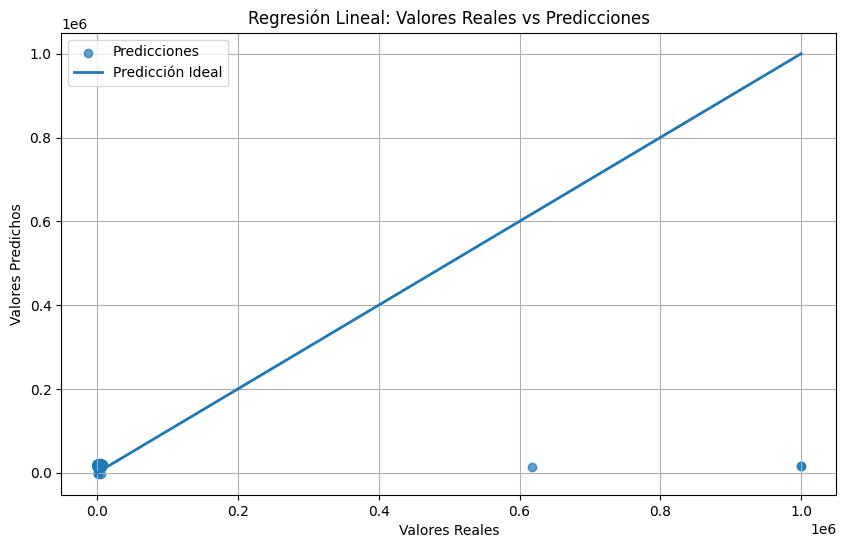


Interpretación: El modelo presenta baja precisión predictiva.


In [116]:
# Crear figura
plt.figure(figsize=(10,6))

# Gráfico de dispersión
plt.scatter(
    y_test,
    predicciones,
    alpha=0.7,
    label="Predicciones"
)

# Línea ideal de predicción
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2,
    label="Predicción Ideal"
)

# PERSONALIZACIÓN

plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")

plt.title(
    "Regresión Lineal: Valores Reales vs Predicciones"
)

plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

# INTERPRETACIÓN AUTOMÁTICA BASADA EN R²

if r2 >= 0.90:
    print("\nInterpretación: El gráfico evidencia un ajuste EXCELENTE del modelo.")
elif r2 >= 0.75:
    print("\nInterpretación: El modelo presenta muy buena relación entre valores reales y predichos.")
elif r2 >= 0.50:
    print("\nInterpretación: El modelo posee una precisión aceptable.")
else:
    print("\nInterpretación: El modelo presenta baja precisión predictiva.")

In [117]:
import pandas as pd
import numpy as np

nuevo_cliente = pd.DataFrame({
    "tenure": [24],
    "MonthlyCharges": [85],
    "Contract": [1],
    "InternetService": [0]
})

# MOSTRAR DATOS

print("\n=== DATOS DEL NUEVO CLIENTE ===\n")
print(nuevo_cliente)

# NORMALIZACIÓN

nuevo_cliente_normalizado = scaler.transform(
    nuevo_cliente
)

# PREDICCIÓN

prediccion = modelo.predict(
    nuevo_cliente_normalizado
)

# RESULTADO

print("\n=== RESULTADO DE LA PREDICCIÓN ===\n")

print(
    f"TotalCharges estimado: {prediccion[0]:.2f}"
)

# INTERPRETACIÓN

print("\n=== INTERPRETACIÓN ===\n")

print(
    "El modelo utilizó las características del nuevo cliente "
    "para generar una predicción basada en los patrones "
    "aprendidos durante el entrenamiento."
)

print(
    f"\nEl valor estimado de TotalCharges es "
    f"{prediccion[0]:.2f}."
)

print(
    "\nEsto representa una estimación calculada "
    "a partir de los datos históricos analizados."
)

# INTERPRETACIÓN AUTOMÁTICA

if prediccion[0] < 100:
    print(
        "\nInterpretación: "
        "El cliente presenta un TotalCharges bajo."
    )

elif prediccion[0] < 500:
    print(
        "\nInterpretación: "
        "El cliente presenta un TotalCharges moderado."
    )

else:
    print(
        "\nInterpretación: "
        "El cliente presenta un TotalCharges elevado."
    )


=== DATOS DEL NUEVO CLIENTE ===

   tenure  MonthlyCharges  Contract  InternetService
0      24              85         1                0

=== RESULTADO DE LA PREDICCIÓN ===

TotalCharges estimado: 21198.25

=== INTERPRETACIÓN ===

El modelo utilizó las características del nuevo cliente para generar una predicción basada en los patrones aprendidos durante el entrenamiento.

El valor estimado de TotalCharges es 21198.25.

Esto representa una estimación calculada a partir de los datos históricos analizados.

Interpretación: El cliente presenta un TotalCharges elevado.


In [118]:
# OPTIMIZACIÓN DE MODELO MACHINE LEARNING
# PASO A PASO CON GridSearchCV

# PASO 1:
# IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# PASO 2:
# SELECCIÓN DE VARIABLES

# Variables predictoras
X = datos[
    [
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService"
    ]
]

# Variable objetivo
y = datos["TotalCharges"]

print("\nVARIABLES SELECCIONADAS ====>\n")

print(X.head())

# PASO 3:
# DIVISIÓN DE DATOS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDATOS DIVIDIDOS CORRECTAMENTE ====>\n")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# PASO 4:
# NORMALIZACIÓN

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\nDATOS NORMALIZADOS ====>\n")

# PASO 5:
# CREACIÓN DEL MODELO BASE

modelo = RandomForestRegressor(
    random_state=42
)

print("\nMODELO BASE CREADO ====>\n")

# PASO 6:
# DEFINICIÓN DE HIPERPARÁMETROS

parametros = {

    "n_estimators": [50, 100, 200],

    "max_depth": [5, 10, 20],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]
}

print("\nHIPERPARÁMETROS DEFINIDOS ====>\n")

print(parametros)

# PASO 7:
# CONFIGURAR GridSearchCV

grid = GridSearchCV(

    estimator=modelo,

    param_grid=parametros,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=1
)

print("\nGridSearchCV CONFIGURADO ====>\n")

# PASO 8:
# ENTRENAMIENTO Y OPTIMIZACIÓN

grid.fit(
    X_train,
    y_train
)

print("\nMODELO OPTIMIZADO CORRECTAMENTE ====>\n")

# PASO 9:
# MEJORES HIPERPARÁMETROS

print("\nMEJORES HIPERPARÁMETROS ====>\n")

print(grid.best_params_)

# PASO 10:
# MEJOR MODELO

mejor_modelo = grid.best_estimator_

print("\nMEJOR MODELO OBTENIDO ====>\n")

print(mejor_modelo)

# PASO 11:
# PREDICCIONES

predicciones = mejor_modelo.predict(
    X_test
)

print("\nPREDICCIONES REALIZADAS ====>\n")

print(predicciones[:10])

# PASO 12:
# MÉTRICAS DE EVALUACIÓN

# MAE

mae = mean_absolute_error(
    y_test,
    predicciones
)

# MSE

mse = mean_squared_error(
    y_test,
    predicciones
)

# RMSE
rmse = np.sqrt(mse)

# R²

r2 = r2_score(
    y_test,
    predicciones
)

# MOSTRAR MÉTRICAS

print("\n=== MÉTRICAS DEL MODELO OPTIMIZADO ===\n")

print(f"MAE  : {mae:.4f}")

print(f"MSE  : {mse:.4f}")

print(f"RMSE : {rmse:.4f}")

print(f"R²   : {r2:.4f}")


# PASO 13:
# INTERPRETACIÓN DE RESULTADOS

print("\n=== INTERPRETACIÓN ===\n")

print(
    f"\nEl modelo obtuvo un R² de {r2:.4f}, "
    "lo que representa su capacidad para explicar "
    "la variabilidad de los datos."
)

print(
    f"\nEl RMSE obtenido fue de {rmse:.4f}, "
    "indicando el nivel promedio de error "
    "en las predicciones."
)

# INTERPRETACIÓN AUTOMÁTICA

if r2 >= 0.90:
    print(
        "\nInterpretación Automática: "
        "El modelo optimizado posee un desempeño EXCELENTE."
    )

elif r2 >= 0.75:
    print(
        "\nInterpretación Automática: "
        "El modelo optimizado presenta muy buena precisión."
    )

elif r2 >= 0.50:
    print(
        "\nInterpretación Automática: "
        "El modelo optimizado posee desempeño aceptable."
    )

else:
    print(
        "\nInterpretación Automática: "
        "El modelo requiere mejoras adicionales."
    )


VARIABLES SELECCIONADAS ====>

   tenure  MonthlyCharges  Contract  InternetService
0     4.0           34.69        16               10
1    55.0           56.56         4                3
2    70.0           56.95        13                3
3    55.0           39.33         9                8
4    49.0          109.32         4                8

DATOS DIVIDIDOS CORRECTAMENTE ====>

X_train: (748, 4)
X_test : (187, 4)

DATOS NORMALIZADOS ====>


MODELO BASE CREADO ====>


HIPERPARÁMETROS DEFINIDOS ====>

{'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

GridSearchCV CONFIGURADO ====>

Fitting 5 folds for each of 81 candidates, totalling 405 fits

MODELO OPTIMIZADO CORRECTAMENTE ====>


MEJORES HIPERPARÁMETROS ====>

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

MEJOR MODELO OBTENIDO ====>

RandomForestRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=10,
     